#TODO

- prova multipli nn su 27 modelli
- function documentation
- import all the functions
- hyperparam refined
- train full df
- predictions



# Project

In [1]:
import pandas as pd
#from thefuzz import process
#from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# For imputation
#from sklearn.experimental import enable_iterative_imputer  # noqa
#from sklearn.impute import IterativeImputer

from scipy import stats
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier #, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor

import numpy as np
from sklearn.base import BaseEstimator, clone
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from typing import Dict

from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.neighbors import KNeighborsRegressor

from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor

import random
from copy import deepcopy
import time

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN

In [2]:
import sys
import os

# Add the current directory to sys.path so we can import from Functions
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

# Import Preprocessing functions
from Functions.preprocessing import (
    simple_processing, 
    remove_price_outliers, 
    fit_transform_encoding, 
    decode, 
    minimal_features
)

# Import Imputation functions
from Functions.imputation import (
    mode_imputation, 
    fit_imputer, 
    apply_imputer, 
    fit_price_imputer, 
    apply_price_imputer
)

In [3]:
train_df = pd.read_csv("https://raw.githubusercontent.com/LiberoBiagi/ML_Nova_IMS_25-26/refs/heads/main/data/train.csv")

In [4]:
train_df = train_df.set_index("carID")
train_df = train_df.drop(columns=["paintQuality%"])

In [5]:
#train_df.head()

### Making sure that the model prices are not typos

In [6]:
"""
#df_cleaned = simple_processing(train_df)
#df_cleaned = df_cleaned[df_cleaned["model"].notna()]
#df_price_model = df_cleaned[["Brand","model", "price"]].copy()

# Get the list of unique models
models = df_price_model['model'].unique()

# Loop through each model and create a boxplot
#for model in models:
sns.catplot(data=df_price_model, y='price', col='model', kind='box', col_wrap=4, height=3, sharey=False)
plt.show()"""

'\n#df_cleaned = simple_processing(train_df)\n#df_cleaned = df_cleaned[df_cleaned["model"].notna()]\n#df_price_model = df_cleaned[["Brand","model", "price"]].copy()\n\n# Get the list of unique models\nmodels = df_price_model[\'model\'].unique()\n\n# Loop through each model and create a boxplot\n#for model in models:\nsns.catplot(data=df_price_model, y=\'price\', col=\'model\', kind=\'box\', col_wrap=4, height=3, sharey=False)\nplt.show()'

## Data cleaning

## Workflow for Train and Validation Sets

TODO: Explanation

#### Encoding

In [7]:
# Fix typos and small numeric cleanup
df = simple_processing(train_df)

# Remove extreme price outliers
df = remove_price_outliers(df)

# Encode cateogrical columns and replace the str with int columns. Return fitted encoders for decoding at the end
df_encoded, encoders = fit_transform_encoding(df)

#### Creating the stratification column

In [8]:
# Create Categorical price column with 0 < 1 < 2 for the price
df_encoded["price_cat"] = pd.qcut(df_encoded["price"], 3, labels=False)

# Combine the 10 unique brand values (1-9 & NA) with the 3 unique price category values (0-2)
stratify_col = df_encoded["Brand_transformed"].astype(str) + "_" + df_encoded["price_cat"].astype(str)

#### Imputation and decoding

In [9]:
# Train validation split
train_split, validation_split = train_test_split(df_encoded, test_size=0.2, random_state=69, stratify=stratify_col)
# train_split, validation_split = train_test_split(df_encoded, test_size=0.2, random_state=42)

# Drop price_cat column from both splits as it would introduce data leakage
train_split = train_split.drop("price_cat", axis=1)
validation_split = validation_split.drop("price_cat", axis=1)

train_split = mode_imputation(train_split)
validation_split = mode_imputation(validation_split)

# Train imputer on train (data leakage risk thus only train on train_split)
imputer = fit_imputer(train_split)

# Apply trained imputer to both datasplits
imputed_train = apply_imputer(train_split, imputer)
imputed_validation = apply_imputer(validation_split, imputer)

# Impute the missing price values created by removing extrem outliers
# In our step to remove extrem price outliers we introduced missing values in the price column. However, in our normal imputer, which we also use for imputing the test 
# Dataset we can not fix these values as this would cause the imputer to not work on the test subset, with no price feature. 
# Thus we create a seperate price imputer to fix the missing values in the testing and validation sets. This imputer is trained on train and applied to validation
# Fit price imputer
price_imputer = fit_price_imputer(imputed_train)
# Apply price imputer
imputed_train = apply_price_imputer(imputed_train, price_imputer)
imputed_validation = apply_price_imputer(imputed_validation, price_imputer)

# Decode encoded columns using the fitted encoders
train_processed = decode(imputed_train, encoders)
validation_processed = decode(imputed_validation, encoders)

c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


## Workflow for Cleaning Testing Dataset

We use all the information available from the training data sets (train and validation splits) to fit imputers and preprocess the testing dataset. This should create a scenario as close to real world deployment as possible, where we use our existing data to process new data entries.

In [10]:
test_df = pd.read_csv("https://raw.githubusercontent.com/LiberoBiagi/ML_Nova_IMS_25-26/refs/heads/main/data/test.csv")

In [11]:
test_df = test_df.set_index("carID")
test_df = test_df.drop(columns=["paintQuality%"])

### Simple pre Imputation processing of Test data

In [12]:
test = simple_processing(test_df)

test_df_encoded, test_encoders = fit_transform_encoding(test)

### Fit the full testing imputer

In [13]:
# Preprocess the full training dataframe from scratch
df = simple_processing(train_df)
df = remove_price_outliers(df)
df_encoded, encoders = fit_transform_encoding(df)
train_df_mode_imputed = mode_imputation(df_encoded)

# Train a full imputer on the all available training data
full_training_imputer = fit_imputer(train_df_mode_imputed)

c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


### Apply the full imputer to the testing data

In [14]:
#df_encoded_no_price = test_df_imputed.drop(["price", "price_cat"], axis=1)

# Apply imputer trained on testing data
test_df_imputed = apply_imputer(test_df_encoded, full_training_imputer)

test_processed = decode(test_df_imputed, test_encoders)

In [15]:
train_val_models = set(pd.concat([train_processed, validation_processed])["model"].unique())
test_models = set(test_processed["model"].unique())

missing_models = train_val_models - test_models


In [16]:
list(missing_models)


['a2',
 'caddy maxi',
 'verso-s',
 '230',
 'ranger',
 '200',
 'accent',
 'getz',
 'kadjar',
 '220',
 'escort',
 'urban cruiser',
 'streetka']

## Checking our data

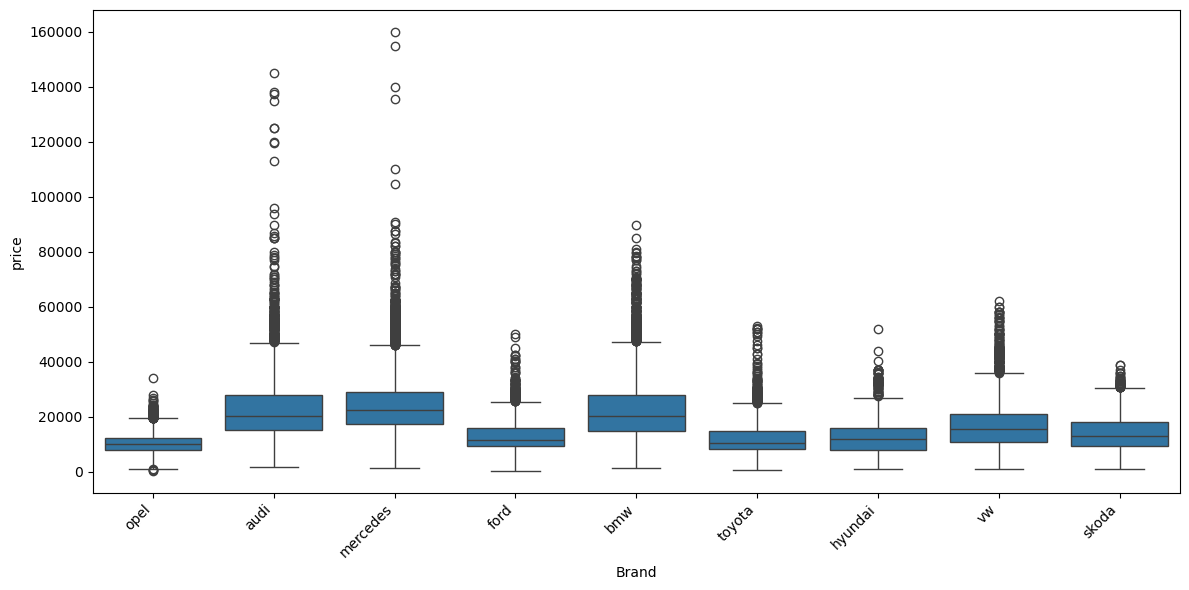

In [17]:
# Boxlpots for every brand.
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_processed, x='Brand', y='price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# There seem to be extreme values in our data for different brands, which might not seem to be outliers when observing our dataset as a whole. 
# We can assume that not only for brands do these types of outliers exist, but also for models. 

In [18]:
def remove_outliers_by_group(df, group_col, value_col, iqr_multiplier=1.5):
    """Remove outliers within each group based on the IQR method."""
    
    def filter_outliers(group):
        Q1 = group[value_col].quantile(0.25)
        Q3 = group[value_col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - iqr_multiplier * IQR
        upper_bound = Q3 + iqr_multiplier * IQR
        
        return group[(group[value_col] >= lower_bound) & (group[value_col] <= upper_bound)]
    
    return df.groupby(group_col, group_keys=False).apply(filter_outliers)

# Remove price outliers for each model separately
train_cleaned = remove_outliers_by_group(train_processed, group_col='model', value_col='price')

# Display statistics
print(f"Original shape: {train_processed.shape}")
print(f"After removing outliers: {train_cleaned.shape}")
print(f"Number of outliers removed: {train_processed.shape[0] - train_cleaned.shape[0]}")
print(f"Percentage of data removed: {((train_processed.shape[0] - train_cleaned.shape[0]) / train_processed.shape[0] * 100):.2f}%")

train_processed = train_cleaned

# It works well but we lose a lot of data. (2.57% if we take the iqr*1.5)

# If this is too much of a loss, we can try a different iqr multiplier, 2x for example.

Original shape: (60778, 12)
After removing outliers: (59297, 12)
Number of outliers removed: 1481
Percentage of data removed: 2.44%


C:\Users\liber\AppData\Local\Temp\ipykernel_41840\2234531507.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_col, group_keys=False).apply(filter_outliers)


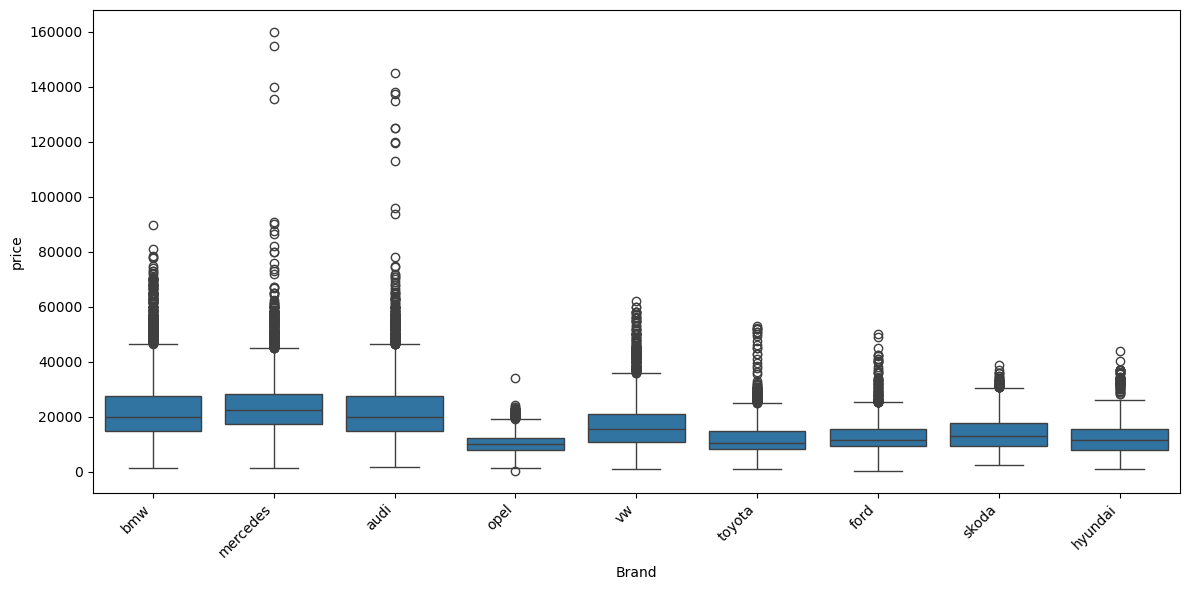

In [19]:
# Visualize boxplot after outlier removal
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_processed, x='Brand', y='price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [20]:
# Checking the audi models with the highest prices
brand_name = 'audi'
brand_avg = train_processed[train_processed['Brand'] == brand_name].groupby('model')['price'].mean().sort_values(ascending=False)
print(brand_avg)
print("\nThe audi cars descending by price:\n")

audi_cars = train_processed[train_processed['Brand'] == 'audi'][['model', 'price']].sort_values('price', ascending=False)
print(audi_cars)

# After cleaning the outliers and looking at the boxplots for all brands audi was seemingly the only brand with large extreme values,
# however these prices all belong to the r8 model which is known to be expensive.

# The cleaning seemed to be effective.

model
r8        96091.666667
q8        56111.533333
ranger    56000.000000
sq7       50470.000000
rs6       49840.500000
              ...     
a2        11686.181818
s5        11495.000000
corsa     10988.000000
ix35      10000.000000
aygo       8490.000000
Name: price, Length: 88, dtype: float64

The audi cars descending by price:

      model     price
10483    r8  145000.0
1082     r8  137995.0
42802    r8  137500.0
16774    r8  135000.0
43634    r8  125000.0
...     ...       ...
38302    a3    2795.0
56952    a4    2675.0
8788     a6    2495.0
46747    a6    2490.0
56299    a4    1699.0

[5840 rows x 2 columns]


## Feature Engineering

In [21]:
train_processed.index = train_processed.index.astype(int)
validation_processed.index = validation_processed.index.astype(int)

In [22]:
X_train = train_processed
X_val = validation_processed

In [23]:
def minimal_features(df):
    df = df.copy()
    df['age'] = 2020 - df['year']
    df = df.drop(columns=["year"])
    df['mileage_per_year'] = df['mileage'] / (df['age'] + 1)
    df['efficiency_ratio'] = df['mpg'] / (df['engineSize'] + 0.1)
    df['age_mileage'] = df['age'] * df['mileage'] / 100000

    return df


In [24]:
X_train = minimal_features(X_train)
X_val = minimal_features(X_val)

In [25]:
model_mean_price = X_train.groupby('model')['price'].mean()

X_train['model_mean_price'] = X_train['model'].map(model_mean_price)
X_val['model_mean_price']   = X_val['model'].map(model_mean_price)


In [26]:
y_train = X_train['price']
y_val = X_val['price']

In [27]:
X_train = X_train.drop(columns=['price'])

X_val = X_val.drop(columns=['price'])


In [28]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 59297 entries, 102 to 60575
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mileage           59297 non-null  int32  
 1   tax               59297 non-null  int32  
 2   mpg               59297 non-null  float64
 3   engineSize        59297 non-null  float64
 4   previousOwners    59297 non-null  int32  
 5   stated_no_damage  59297 non-null  float64
 6   Brand             59297 non-null  object 
 7   transmission      59297 non-null  object 
 8   model             59297 non-null  object 
 9   fuelType          59297 non-null  object 
 10  age               59297 non-null  int32  
 11  mileage_per_year  59297 non-null  float64
 12  efficiency_ratio  59297 non-null  float64
 13  age_mileage       59297 non-null  float64
 14  model_mean_price  59297 non-null  float64
dtypes: float64(7), int32(4), object(4)
memory usage: 6.1+ MB


In [29]:
X_val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15195 entries, 0 to 15194
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mileage           15195 non-null  int32  
 1   tax               15195 non-null  int32  
 2   mpg               15195 non-null  float64
 3   engineSize        15195 non-null  float64
 4   previousOwners    15195 non-null  int32  
 5   stated_no_damage  15195 non-null  float64
 6   Brand             15195 non-null  object 
 7   transmission      15195 non-null  object 
 8   model             15195 non-null  object 
 9   fuelType          15195 non-null  object 
 10  age               15195 non-null  int32  
 11  mileage_per_year  15195 non-null  float64
 12  efficiency_ratio  15195 non-null  float64
 13  age_mileage       15195 non-null  float64
 14  model_mean_price  15195 non-null  float64
dtypes: float64(7), int32(4), object(4)
memory usage: 1.6+ MB


In [30]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 59297 entries, 102 to 60575
Series name: price
Non-Null Count  Dtype  
--------------  -----  
59297 non-null  float64
dtypes: float64(1)
memory usage: 694.9 KB


In [31]:
y_val.info()

<class 'pandas.core.series.Series'>
Index: 15195 entries, 0 to 15194
Series name: price
Non-Null Count  Dtype  
--------------  -----  
15195 non-null  float64
dtypes: float64(1)
memory usage: 178.1 KB


## Test of the models on the full dataset

In [32]:
class BrandModelTrainer:
    def __init__(self, estimator):
        self.estimator = estimator
        self.brand_models = {}
        self.feature_cols = None

    def fit(self, X_train, y_train):
        self.feature_cols = [c for c in X_train.columns if c != "Brand"]
        print(f"Training models for {len(X_train['Brand'].unique())} brands...\n")

        for brand in X_train["Brand"].unique():
            mask = X_train["Brand"] == brand
            Xb = X_train.loc[mask, self.feature_cols]
            yb = y_train[mask]

            numeric_cols = Xb.select_dtypes(include=["int64", "int32" ,"float64"]).columns.tolist()
            categorical_cols = Xb.select_dtypes(include=["object", "category"]).columns.tolist()

            preprocessor = ColumnTransformer([
                ("num", RobustScaler(), numeric_cols),
                ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
            ])

            model = Pipeline([
                ("preprocess", preprocessor),
                ("estimator", clone(self.estimator))
            ])

            model.fit(Xb, yb)
            self.brand_models[brand] = model
            print(f"  ✓ {brand} done.")

        return self

    def predict(self, X):
        preds = np.zeros(len(X))
        for brand, model in self.brand_models.items():
            mask = X["Brand"] == brand
            if mask.sum() == 0:
                continue
            Xb = X.loc[mask, self.feature_cols]
            preds[mask] = model.predict(Xb)
        return preds

    def evaluate_train(self, X_train, y_train):
        y_pred = self.predict(X_train)
        rmse = np.sqrt(mean_squared_error(y_train, y_pred))
        mae = mean_absolute_error(y_train, y_pred)
        r2 = r2_score(y_train, y_pred)
        print("\nTraining Set Performance (Overall):")
        print(f"  RMSE: {rmse:.2f}")
        print(f"  MAE:  {mae:.2f}")
        print(f"  R²:   {r2:.4f}")
        return {"RMSE": rmse, "MAE": mae, "R²": r2}

    def evaluate(self, X_val, y_val):
        y_pred = self.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        mae = mean_absolute_error(y_val, y_pred)
        r2 = r2_score(y_val, y_pred)
        print("\nValidation Set Performance (Overall):")
        print(f"  RMSE: {rmse:.2f}")
        print(f"  MAE:  {mae:.2f}")
        print(f"  R²:   {r2:.4f}")
        return {"RMSE": rmse, "MAE": mae, "R²": r2}

    def evaluate_by_brand(self, X, y, split_name="Validation"):
        y_pred = self.predict(X)
        results = []
        for brand in X["Brand"].unique():
            mask = X["Brand"] == brand
            y_true_b = y[mask]
            y_pred_b = y_pred[mask]
            rmse = np.sqrt(mean_squared_error(y_true_b, y_pred_b))
            mae = mean_absolute_error(y_true_b, y_pred_b)
            r2 = r2_score(y_true_b, y_pred_b)
            results.append({"Brand": brand, "N": len(y_true_b), "RMSE": rmse, "MAE": mae, "R²": r2})
        df = pd.DataFrame(results).sort_values("RMSE")
        print(f"\n{split_name} Performance per Brand:")
        print(df.to_string(index=False))
        return df

    def evaluate_train_by_brand(self, X_train, y_train):
        return self.evaluate_by_brand(X_train, y_train, split_name="Training")
    
    def save_predictions(self, X, path):
        preds = self.predict(X)
        df = pd.DataFrame({
            "CarID": X["CarID"].values,
            "price": preds
        })
        df.to_csv(path, index=False)
        print(f"File salvato in: {path}")
        return df


In [33]:
raise SystemExit("Stop before training the models")

SystemExit: Stop before training the models

C:\Users\liber\AppData\Roaming\Python\Python311\site-packages\IPython\core\interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


### Linear Regression

In [34]:
LR = LinearRegression()
trainer = BrandModelTrainer(LR)

# fit
trainer.fit(X_train, y_train)

# performance overall
trainer.evaluate_train(X_train, y_train)
trainer.evaluate(X_val, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train, y_train)
trainer.evaluate_by_brand(X_val, y_val)

Training models for 9 brands...

  ✓ bmw done.
  ✓ mercedes done.
  ✓ audi done.
  ✓ opel done.
  ✓ vw done.
  ✓ toyota done.
  ✓ ford done.
  ✓ skoda done.
  ✓ hyundai done.

Training Set Performance (Overall):
  RMSE: 2863.16
  MAE:  1844.43
  R²:   0.9027

Validation Set Performance (Overall):
  RMSE: 3161.14
  MAE:  1999.34
  R²:   0.8900

Training Performance per Brand:
   Brand     N        RMSE         MAE       R²
    opel  7388 1260.009980  929.758128 0.856345
  toyota  3669 1531.470606 1009.202218 0.934754
    ford 12852 1787.208949 1324.010326 0.844589
   skoda  3440 1875.330652 1354.962077 0.902648
 hyundai  2576 1915.780313 1339.325694 0.884922
      vw  8264 2651.381734 1868.306638 0.876726
    audi  5840 3607.582643 2434.447071 0.895090
     bmw  5946 3777.232134 2631.495487 0.884193
mercedes  9322 4445.499005 3042.935195 0.786637

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1908 1623.604942 1102.531207 0.793186
   skoda  881

,Brand,N,RMSE,MAE,R²
7,opel,1908,1623.604942,1102.531207,0.793186
8,skoda,881,1936.717848,1415.871977,0.901664
3,toyota,940,1979.324468,1174.564183,0.913357
1,ford,3279,2064.536175,1414.952266,0.812013
5,hyundai,687,2066.886245,1455.141922,0.875996
0,vw,2125,2877.397498,2045.615732,0.862950
2,bmw,1505,4006.169159,2763.405174,0.875001
6,audi,1490,4060.187422,2693.230951,0.870866
4,mercedes,2380,4876.700542,3263.373267,0.784194


### Decision Tree

In [35]:
Tree = DecisionTreeRegressor(criterion="absolute_error")
trainer = BrandModelTrainer(Tree)

# fit
trainer.fit(X_train, y_train)

# performance overall
trainer.evaluate_train(X_train, y_train)
trainer.evaluate(X_val, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train, y_train)
trainer.evaluate_by_brand(X_val, y_val)        # Performance VALID

Training models for 9 brands...

  ✓ bmw done.
  ✓ mercedes done.
  ✓ audi done.
  ✓ opel done.
  ✓ vw done.
  ✓ toyota done.
  ✓ ford done.
  ✓ skoda done.
  ✓ hyundai done.

Training Set Performance (Overall):
  RMSE: 100.77
  MAE:  5.53
  R²:   0.9999

Validation Set Performance (Overall):
  RMSE: 2804.62
  MAE:  1637.47
  R²:   0.9134

Training Performance per Brand:
   Brand     N       RMSE       MAE       R²
  toyota  3669  37.026688  1.617607 0.999962
   skoda  3440  37.902698  2.059302 0.999960
    ford 12852  60.407729  3.282291 0.999822
      vw  8264  72.793078  5.209826 0.999907
    opel  7388  76.552770  7.213996 0.999470
    audi  5840  92.290027  4.211986 0.999931
 hyundai  2576 125.583209  8.032997 0.999506
     bmw  5946 125.840753  3.847629 0.999871
mercedes  9322 171.351204 11.599120 0.999683

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1908 1573.336160 1044.622239 0.805794
    ford 3279 1811.892223 1141.332340 0.855207


,Brand,N,RMSE,MAE,R²
7,opel,1908,1573.336160,1044.622239,0.805794
1,ford,3279,1811.892223,1141.332340,0.855207
5,hyundai,687,1850.162825,1219.869080,0.900638
8,skoda,881,1860.523435,1272.766372,0.909250
3,toyota,940,2057.673237,1232.999411,0.906362
0,vw,2125,2563.297115,1606.725892,0.891238
6,audi,1490,3477.186009,2226.731921,0.905288
2,bmw,1505,3627.908985,2231.040944,0.897492
4,mercedes,2380,4243.987645,2494.784242,0.836560


### KNR

In [36]:
KNR = KNeighborsRegressor()
trainer = BrandModelTrainer(KNR)

# fit
trainer.fit(X_train, y_train)

# performance overall
trainer.evaluate_train(X_train, y_train)
trainer.evaluate(X_val, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train, y_train)
trainer.evaluate_by_brand(X_val, y_val)

Training models for 9 brands...

  ✓ bmw done.
  ✓ mercedes done.
  ✓ audi done.
  ✓ opel done.
  ✓ vw done.
  ✓ toyota done.
  ✓ ford done.
  ✓ skoda done.
  ✓ hyundai done.

Training Set Performance (Overall):
  RMSE: 1844.50
  MAE:  1169.42
  R²:   0.9596

Validation Set Performance (Overall):
  RMSE: 2813.15
  MAE:  1605.49
  R²:   0.9129

Training Performance per Brand:
   Brand     N        RMSE         MAE       R²
    opel  7388  927.819347  649.001726 0.922107
    ford 12852 1167.564070  812.131763 0.933672
  toyota  3669 1180.144738  763.098785 0.961256
 hyundai  2576 1358.358759  869.211496 0.942146
   skoda  3440 1407.143670  992.272649 0.945189
      vw  8264 1776.812073 1183.839376 0.944638
    audi  5840 2486.943766 1668.884343 0.950144
     bmw  5946 2543.477367 1688.637917 0.947490
mercedes  9322 2547.748060 1725.847640 0.929921

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1908 1392.251617  924.335601 0.847926
   skoda  881

,Brand,N,RMSE,MAE,R²
7,opel,1908,1392.251617,924.335601,0.847926
8,skoda,881,1706.297685,1231.049456,0.923671
1,ford,3279,1721.765626,1057.209092,0.869253
5,hyundai,687,1835.970736,1180.811092,0.902156
3,toyota,940,1882.090554,1059.499233,0.921661
0,vw,2125,2300.696528,1555.476243,0.912381
6,audi,1490,3557.936695,2258.655142,0.900838
2,bmw,1505,3641.535380,2300.175846,0.896720
4,mercedes,2380,4516.715269,2580.248153,0.814879


### Random Forest

In [37]:
RF = RandomForestRegressor(random_state=69)
rf_trainer = BrandModelTrainer(RF)


rf_trainer.fit(X_train, y_train)


rf_trainer.evaluate_train(X_train, y_train)
rf_trainer.evaluate(X_val, y_val)

rf_trainer.evaluate_train_by_brand(X_train, y_train)
rf_trainer.evaluate_by_brand(X_val, y_val)



Training models for 9 brands...

  ✓ bmw done.
  ✓ mercedes done.
  ✓ audi done.
  ✓ opel done.
  ✓ vw done.
  ✓ toyota done.
  ✓ ford done.
  ✓ skoda done.
  ✓ hyundai done.

Training Set Performance (Overall):
  RMSE: 733.67
  MAE:  446.32
  R²:   0.9936

Validation Set Performance (Overall):
  RMSE: 2280.87
  MAE:  1304.06
  R²:   0.9427

Training Performance per Brand:
   Brand     N        RMSE        MAE       R²
    opel  7388  388.594301 276.956640 0.986336
    ford 12852  490.180852 333.638526 0.988309
 hyundai  2576  527.306305 340.204603 0.991282
  toyota  3669  530.068108 318.791556 0.992184
   skoda  3440  572.186829 390.781903 0.990937
      vw  8264  680.878584 434.182883 0.991870
    audi  5840  890.890245 594.672876 0.993602
     bmw  5946  946.968856 605.710859 0.992721
mercedes  9322 1088.390465 652.085984 0.987211

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1908 1267.343462  841.328444 0.873989
 hyundai  687 1488.514627

,Brand,N,RMSE,MAE,R²
7,opel,1908,1267.343462,841.328444,0.873989
5,hyundai,687,1488.514627,998.714341,0.935686
3,toyota,940,1492.948165,962.594647,0.950707
1,ford,3279,1493.403627,933.048604,0.901636
8,skoda,881,1499.416687,1041.034114,0.941058
0,vw,2125,1883.612681,1236.107127,0.941270
2,bmw,1505,2893.906605,1722.334333,0.934775
6,audi,1490,2942.646128,1777.920001,0.932169
4,mercedes,2380,3552.075286,2006.038842,0.885508


### Neural Network

In [ ]:
from sklearn.neural_network import MLPRegressor

mlp_deep = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),  
    activation='relu',
    solver='adam',
    alpha=0.001,  
    learning_rate_init=0.005,
    learning_rate='adaptive',
    max_iter=2000,
    batch_size=512,
    random_state=69,
    early_stopping=True,
    n_iter_no_change=30,  
    validation_fraction=0.15,
    verbose=True
)

mlp_trainer = BrandModelTrainer(mlp_deep)


mlp_trainer.fit(X_train, y_train)


mlp_trainer.evaluate_train(X_train, y_train)
mlp_trainer.evaluate(X_val, y_val)


mlp_trainer.evaluate_train_by_brand(X_train, y_train)
mlp_trainer.evaluate_by_brand(X_val, y_val)

Training models for 9 brands...

Iteration 1, loss = 313630247.20135546
Validation score: -4.044444
Iteration 2, loss = 312642587.43732214
Validation score: -4.007396
Iteration 3, loss = 307424947.60229886
Validation score: -3.837739
Iteration 4, loss = 288529716.28073227
Validation score: -3.296725
Iteration 5, loss = 237165448.16663647
Validation score: -2.017972
Iteration 6, loss = 135404755.86948398
Validation score: -0.095580
Iteration 7, loss = 38156781.78448893
Validation score: 0.487045
Iteration 8, loss = 28047094.30047049
Validation score: 0.655555
Iteration 9, loss = 15171047.84219072
Validation score: 0.739139
Iteration 10, loss = 12501380.41139105
Validation score: 0.804967
Iteration 11, loss = 9837203.38484907
Validation score: 0.824073
Iteration 12, loss = 8735863.63947792
Validation score: 0.840705
Iteration 13, loss = 8155071.56829787
Validation score: 0.847379
Iteration 14, loss = 7744281.52964634
Validation score: 0.853109
Iteration 15, loss = 7516664.43736370
Valida

c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:788: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


  ✓ bmw done.
Iteration 1, loss = 327749714.20301074
Validation score: -6.965909
Iteration 2, loss = 321150854.78040600
Validation score: -6.529901
Iteration 3, loss = 278279823.64795321
Validation score: -4.483227
Iteration 4, loss = 153791290.45592406
Validation score: -0.762910
Iteration 5, loss = 49117179.73216745
Validation score: 0.391489
Iteration 6, loss = 21654412.90878659
Validation score: 0.620389
Iteration 7, loss = 15885689.63370420
Validation score: 0.703633
Iteration 8, loss = 13346070.73383903
Validation score: 0.747233
Iteration 9, loss = 11762391.65361501
Validation score: 0.774898
Iteration 10, loss = 10856410.13755236
Validation score: 0.790370
Iteration 11, loss = 10255245.57638115
Validation score: 0.799711


### Performance

| *Model* | *RMSE* | *MAE* | *R²* |
|---------|--------|--------|------|
| Linear Regression | 3383.27 | 2156.67 | 0.8723 |
| Tree | 2784.00 | 1663.58 | 0.9135 |
| KNR|2623.89 |1599.60 |0.9232 |
|RF | 2032.89 |1258.34 |0.9539 |
|NN | 2319.24 |1466.96 |0.9400 |


 

## Feature selection - Filter Methods

In [ ]:
df = X_train.join(y_train)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60778 entries, 0 to 60777
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mileage           60778 non-null  int32  
 1   tax               60778 non-null  int32  
 2   mpg               60778 non-null  float64
 3   engineSize        60778 non-null  float64
 4   previousOwners    60778 non-null  int32  
 5   Brand             60778 non-null  object 
 6   age               60778 non-null  int32  
 7   mileage_per_year  60778 non-null  float64
 8   efficiency_ratio  60778 non-null  float64
 9   age_mileage       60778 non-null  float64
 10  model_mean_price  60778 non-null  float64
 11  price             60778 non-null  float64
dtypes: float64(7), int32(4), object(1)
memory usage: 4.9+ MB


In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
y = df['price']

numerical_cols = df.select_dtypes(include=['int64', "int32",'float64']).columns

# Drop 'carID' and 'price'
num_cols = [col for col in numerical_cols 
            if "_transformed" not in col and col not in ['price', 'carID']]

print(num_cols)
print(categorical_cols)

['mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'age', 'mileage_per_year', 'efficiency_ratio', 'age_mileage', 'model_mean_price']
['Brand']


In [ ]:
#FILTER METHOD


#ANOVA FUNCTION

def anova_for_categorical(df, y, categorical_cols):
    # Align indices between df and y
    common_idx = df.index.intersection(y.index)
    df_aligned = df.loc[common_idx]
    y_aligned = y.loc[common_idx]
    
    f_scores, p_values = [], []
    for col in df_aligned.columns:
        if col in categorical_cols:
            groups = [y_aligned[df_aligned[col] == cat] for cat in df_aligned[col].dropna().unique()]
            if len(groups) > 1 and all(len(g) > 1 for g in groups):
                f_stat, p_val = stats.f_oneway(*groups)
            else:
                f_stat, p_val = 0.0, 1.0
        else:
            if df_aligned[col].nunique() > 1:
                # Remove NaN values for correlation calculation
                valid_idx = df_aligned[col].notna() & y_aligned.notna()
                if valid_idx.sum() > 1:
                    corr = np.corrcoef(df_aligned.loc[valid_idx, col], y_aligned[valid_idx])[0, 1]
                    f_stat = corr**2 * valid_idx.sum()
                    p_val = 0.0
                else:
                    f_stat, p_val = 0.0, 1.0
            else:
                f_stat, p_val = 0.0, 1.0
        f_scores.append(f_stat)
        p_values.append(p_val)
    
    return np.array(f_scores), np.array(p_values)


def filter_method_selection(X_train, y_train, categorical_cols, num_cols,
                            top_k=None,
                            var_threshold=0.01,
                            corr_threshold=0.85):
    
    print("FILTER METHOD (Variance + Spearman Correlation + ANOVA)")
    
    # Ensure indices match
    common_idx = X_train.index.intersection(y_train.index)
    X_train = X_train.loc[common_idx]
    y_train = y_train.loc[common_idx]
    
    # Filter numerical columns that exist in X_train
    num_cols_in_X = [col for col in num_cols if col in X_train.columns]
    
    # Variance Threshold
    if num_cols_in_X:
        vt_selector = VarianceThreshold(threshold=var_threshold)
        X_num_vt = pd.DataFrame(
            vt_selector.fit_transform(X_train[num_cols_in_X]),
            columns=np.array(num_cols_in_X)[vt_selector.get_support()],
            index=X_train.index
        )
        print(f"Removed {len(num_cols_in_X) - X_num_vt.shape[1]} low-variance numeric features.")
    else:
        X_num_vt = pd.DataFrame(index=X_train.index)
    
    # Spearman Correlation
    if not X_num_vt.empty and X_num_vt.shape[1] > 1:
        corr_matrix = X_num_vt.corr(method='spearman').abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop = [col for col in upper.columns if any(upper[col] > corr_threshold)]
        X_num_corr = X_num_vt.drop(columns=to_drop)
        print(f"Removed {len(to_drop)} correlated numeric features (Spearman |corr| > {corr_threshold}).")
    else:
        X_num_corr = X_num_vt
    
    # Filter categorical columns that exist in X_train
    categorical_cols_in_X = [col for col in categorical_cols if col in X_train.columns]
    
    # Combine numeric + categorical
    X_filtered = pd.concat([X_num_corr, X_train[categorical_cols_in_X]], axis=1)
    
    # ANOVA F-test
    f_scores, f_pvalues = anova_for_categorical(X_filtered, y_train, categorical_cols_in_X)
    f_norm = (f_scores - f_scores.min()) / (f_scores.max() - f_scores.min() + 1e-10)
    
    results_df = pd.DataFrame({
        'feature': X_filtered.columns,
        'ANOVA_F': f_scores,
        'ANOVA_p_value': f_pvalues,
        'ANOVA_norm': f_norm,
        'type': ['categorical' if c in categorical_cols_in_X else 'numerical' for c in X_filtered.columns]
    }).sort_values('ANOVA_norm', ascending=False)
    
    if top_k is None:
        selected_features = X_filtered.columns.tolist()
    else:
        selected_features = X_filtered.columns[np.argsort(f_norm)[-top_k:]].tolist()
    
    print(f"\nFilter method selected {len(selected_features)} features")
    
    return selected_features, X_filtered[selected_features], results_df



In [ ]:
y = df["price"]

df = df.drop(columns=["price"])

In [ ]:

#X_train = df[num_cols]
#y_train = df['price']

# Filter method (Variance + Spearman + ANOVA)
# Define categorical and numerical columns first (if not already defined)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(include=['int64',"int32", 'float64']).columns.tolist()

# Filter method with all required parameters
selected_filter, X_train_filtered, filter_df = filter_method_selection(
    df, 
    y,
    categorical_cols=categorical_cols,  # Add this
    num_cols=num_cols,                  # Add this
    top_k=None, 
    var_threshold=0.01, 
    corr_threshold=0.85
)

# Print features selected
print("\nFeatures selected by Filter Method:")
for f in selected_filter:
    print(f)

# Display feature importance scores
print("\nTop 10 Features by ANOVA Score:")
print(filter_df.head(10))



FILTER METHOD (Variance + Spearman Correlation + ANOVA)
Removed 0 low-variance numeric features.
Removed 2 correlated numeric features (Spearman |corr| > 0.85).

Filter method selected 9 features

Features selected by Filter Method:
mileage
tax
mpg
engineSize
previousOwners
age
efficiency_ratio
model_mean_price
Brand

Top 10 Features by ANOVA Score:
            feature       ANOVA_F  ANOVA_p_value  ANOVA_norm         type
7  model_mean_price  34640.642682            0.0    1.000000    numerical
3        engineSize  22794.634110            0.0    0.658031    numerical
5               age  14616.426835            0.0    0.421944    numerical
0           mileage  10574.395929            0.0    0.305260    numerical
1               tax   5805.947358            0.0    0.167605    numerical
2               mpg   5420.087323            0.0    0.156466    numerical
8             Brand   3198.955108            0.0    0.092347  categorical
6  efficiency_ratio    590.142312            0.0    0.01

In [ ]:
raise SystemExit("Stop before training the models")

SystemExit: Stop before training the models

C:\Users\liber\AppData\Roaming\Python\Python311\site-packages\IPython\core\interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## Test models on reduced DF

In [ ]:
X_train_filter = X_train[["mileage", "tax", "mpg", "engineSize", "previousOwners", "age", "efficiency_ratio", 
                          "Brand", "model_mean_price"]]
X_train_filter

,mileage,tax,mpg,engineSize,previousOwners,age,efficiency_ratio,Brand,model_mean_price
0,11899,125,51.4,1.4,2,4,34.266667,opel,10544.969916
1,18500,145,48.7,1.4,4,2,32.466667,audi,22941.135849
2,10658,145,46.3,1.5,2,1,28.937500,mercedes,23614.274992
3,1500,145,43.5,0.0,4,0,435.000000,audi,22668.695652
4,18495,97,64.2,2.1,4,3,29.181818,mercedes,23614.274992
...,...,...,...,...,...,...,...,...,...
60773,14867,150,55.4,1.4,3,2,36.933333,opel,8341.249091
60774,20100,145,52.3,1.2,3,2,40.230769,toyota,12433.806533
60775,10498,145,68.9,1.0,0,2,62.636364,toyota,7989.355040
60776,17502,145,40.4,2.0,4,3,19.238095,audi,30343.451883


In [ ]:
X_val_filter = X_val[["mileage", "tax", "mpg", "engineSize", "previousOwners", "age", "efficiency_ratio", 
                          "Brand", "model_mean_price"]]

X_val_filter

,mileage,tax,mpg,engineSize,previousOwners,age,efficiency_ratio,Brand,model_mean_price
0,14774,145,53.3,2.0,0,1,25.380952,vw,16838.245902
1,16375,150,47.9,1.6,4,4,28.176471,ford,10253.780457
2,32746,265,37.2,3.0,3,4,12.000000,bmw,19666.681818
3,10164,145,68.9,1.5,3,1,43.062500,bmw,15831.478771
4,11407,145,80.7,1.5,2,1,50.437500,ford,13405.063178
...,...,...,...,...,...,...,...,...,...
15190,10766,20,51.4,1.4,2,1,34.266667,opel,10544.969916
15191,5000,145,48.7,2.0,1,0,23.190476,vw,16838.245902
15192,28056,145,60.1,2.0,0,3,28.619048,ford,15820.286791
15193,25169,145,56.5,1.0,4,2,51.363636,ford,10253.780457


### Linear Regression

In [ ]:
LR = LinearRegression()
trainer = BrandModelTrainer(LR)

# fit
trainer.fit(X_train_filter, y_train)

# performance overall
trainer.evaluate_train(X_train_filter, y_train)
trainer.evaluate(X_val_filter, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train_filter, y_train)
trainer.evaluate_by_brand(X_val_filter, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 3753.05
  MAE:  2349.33
  R²:   0.8472

Validation Set Performance (Overall):
  RMSE: 3693.99
  MAE:  2370.68
  R²:   0.8488

Training Performance per Brand:
   Brand     N        RMSE         MAE       R²
    opel  7642 1911.425486 1332.067636 0.711681
    ford 13112 2250.544491 1603.984474 0.776183
  toyota  3775 2672.425152 1668.664081 0.813951
 hyundai  2720 2732.839364 1881.099809 0.791682
   skoda  3505 2811.813290 1899.433972 0.789122
      vw  8479 3520.602454 2348.880949 0.791689
    audi  5970 4804.117879 3107.878661 0.830603
     bmw  6038 4999.391914 3430.823224 0.806088
mercedes  9537 5542.528955 3598.367659 0.727973

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1908 2001.536126 1373.473245 0.683073
    ford 3279

,Brand,N,RMSE,MAE,R²
7,opel,1908,2001.536126,1373.473245,0.683073
1,ford,3279,2346.202490,1591.457628,0.757236
8,skoda,881,2526.238826,1799.485378,0.832664
5,hyundai,686,2833.977705,1944.501152,0.778963
3,toyota,940,3103.031629,1817.468692,0.787047
0,vw,2125,3563.667737,2456.090135,0.789784
6,audi,1490,4632.794229,3105.265143,0.831849
2,bmw,1505,5039.958678,3454.809357,0.802168
4,mercedes,2381,5195.579270,3574.220922,0.748896


### Single tree

In [ ]:
Tree = DecisionTreeRegressor(criterion="absolute_error")
trainer = BrandModelTrainer(Tree)

# fit
trainer.fit(X_train_filter, y_train)

# performance overall
trainer.evaluate_train(X_train_filter, y_train)
trainer.evaluate(X_val_filter, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train_filter, y_train)
trainer.evaluate_by_brand(X_val_filter, y_val)        # Performance VALID

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 124.84
  MAE:  7.41
  R²:   0.9998

Validation Set Performance (Overall):
  RMSE: 2826.88
  MAE:  1687.90
  R²:   0.9114

Training Performance per Brand:
   Brand     N       RMSE       MAE       R²
  toyota  3775  38.713191  1.969536 0.999961
    ford 13112  61.755492  3.460723 0.999831
 hyundai  2720  82.107850  4.209926 0.999812
   skoda  3505  85.636946  4.819401 0.999804
      vw  8479 110.937540  7.771907 0.999793
    opel  7642 117.617117 10.566867 0.998908
     bmw  6038 134.317929  5.093408 0.999860
mercedes  9537 170.455434 12.065010 0.999743
    audi  5970 205.186293 12.843886 0.999691

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1908 1625.140082 1054.305909 0.791063
   skoda  881 1899.684808 1341.645848 0.905375


,Brand,N,RMSE,MAE,R²
7,opel,1908,1625.140082,1054.305909,0.791063
8,skoda,881,1899.684808,1341.645848,0.905375
1,ford,3279,1900.412530,1195.911875,0.840725
5,hyundai,686,1992.375586,1268.721790,0.890752
3,toyota,940,2342.063819,1334.011995,0.878687
0,vw,2125,2841.210728,1707.615805,0.866378
6,audi,1490,3444.895132,2229.002731,0.907025
2,bmw,1505,3763.453799,2436.753173,0.889690
4,mercedes,2381,3959.817250,2432.239015,0.854140


In [ ]:
KNR = KNeighborsRegressor()
trainer = BrandModelTrainer(KNR)

# fit
trainer.fit(X_train_filter, y_train)

# performance overall
trainer.evaluate_train(X_train_filter, y_train)
trainer.evaluate(X_val_filter, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train_filter, y_train)
trainer.evaluate_by_brand(X_val_filter, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 2052.49
  MAE:  1266.52
  R²:   0.9543

Validation Set Performance (Overall):
  RMSE: 2551.80
  MAE:  1583.93
  R²:   0.9278

Training Performance per Brand:
   Brand     N        RMSE         MAE       R²
    opel  7642 1070.603900  728.910498 0.909548
    ford 13112 1255.571666  853.682504 0.930337
  toyota  3775 1445.847883  907.723008 0.945542
 hyundai  2720 1538.841436  997.148215 0.933948
   skoda  3505 1581.873320 1141.278821 0.933258
      vw  8479 1877.048989 1249.628294 0.940785
    audi  5970 2756.317484 1785.863027 0.944238
mercedes  9537 2772.715162 1803.095789 0.931922
     bmw  6038 3016.926477 1924.486237 0.929385

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1908 1461.738583  960.241937 0.830967
    ford 3279

,Brand,N,RMSE,MAE,R²
7,opel,1908,1461.738583,960.241937,0.830967
1,ford,3279,1669.267462,1055.694921,0.877113
8,skoda,881,1792.511188,1344.064579,0.915751
5,hyundai,686,1887.425073,1237.538877,0.901958
3,toyota,940,2111.747432,1236.005019,0.901373
0,vw,2125,2306.162349,1560.572013,0.911966
6,audi,1490,3106.042203,2098.551144,0.924416
2,bmw,1505,3554.894207,2356.251417,0.901577
4,mercedes,2381,3641.271633,2347.716357,0.876663


In [ ]:
RF = RandomForestRegressor(random_state=69)
rf_trainer = BrandModelTrainer(RF)


rf_trainer.fit(X_train_filter, y_train)


rf_trainer.evaluate_train(X_train_filter, y_train)
rf_trainer.evaluate(X_val_filter, y_val)

rf_trainer.evaluate_train_by_brand(X_train_filter, y_train)
rf_trainer.evaluate_by_brand(X_val_filter, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 804.75
  MAE:  481.84
  R²:   0.9930

Validation Set Performance (Overall):
  RMSE: 2077.84
  MAE:  1297.00
  R²:   0.9522

Training Performance per Brand:
   Brand     N        RMSE        MAE       R²
    opel  7642  458.246193 304.946080 0.983429
    ford 13112  512.799369 346.710885 0.988380
  toyota  3775  573.418168 348.071296 0.991434
 hyundai  2720  594.854229 364.325050 0.990130
   skoda  3505  638.340715 427.893713 0.989132
      vw  8479  729.660223 469.145485 0.991052
    audi  5970 1041.421534 657.526502 0.992040
     bmw  6038 1084.746132 666.043754 0.990871
mercedes  9537 1148.636944 700.325267 0.988317

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1908 1269.021298  825.545612 0.872600
    ford 3279 1451.811387

,Brand,N,RMSE,MAE,R²
7,opel,1908,1269.021298,825.545612,0.872600
1,ford,3279,1451.811387,929.913727,0.907045
3,toyota,940,1463.874877,966.070750,0.952606
8,skoda,881,1504.720182,1074.616650,0.940632
5,hyundai,686,1546.963989,981.260630,0.934138
0,vw,2125,1945.441189,1265.063617,0.937352
6,audi,1490,2569.898243,1726.145547,0.948258
2,bmw,1505,2821.190373,1797.286556,0.938012
4,mercedes,2381,2905.996708,1927.985693,0.921445


### Neural Network

In [ ]:
from sklearn.neural_network import MLPRegressor

mlp_deep = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),  
    activation='relu',
    solver='adam',
    alpha=0.001,  
    learning_rate_init=0.005,
    learning_rate='adaptive',
    max_iter=2000,
    batch_size=512,
    random_state=69,
    early_stopping=True,
    n_iter_no_change=30,  
    validation_fraction=0.15,
    verbose=True
)

mlp_trainer = BrandModelTrainer(mlp_deep)


mlp_trainer.fit(X_train_filter, y_train)


mlp_trainer.evaluate_train(X_train_filter, y_train)
mlp_trainer.evaluate(X_val_filter, y_val)


mlp_trainer.evaluate_train_by_brand(X_train_filter, y_train)
mlp_trainer.evaluate_by_brand(X_val_filter, y_val)

Training models for 9 brands...

Iteration 1, loss = 60287421.80712822
Validation score: -8.342129
Iteration 2, loss = 59812343.27538614
Validation score: -8.158262
Iteration 3, loss = 57202423.96638063
Validation score: -7.357252
Iteration 4, loss = 48647660.87378047
Validation score: -5.305369
Iteration 5, loss = 32602291.37703187
Validation score: -2.700842
Iteration 6, loss = 19294385.06860101
Validation score: -1.064464
Iteration 7, loss = 11602525.27480094
Validation score: -0.348987
Iteration 8, loss = 8244692.71516285
Validation score: -0.074719
Iteration 9, loss = 6563660.89551724
Validation score: 0.089837
Iteration 10, loss = 5499071.70257259
Validation score: 0.223465
Iteration 11, loss = 4604778.24540892
Validation score: 0.345084
Iteration 12, loss = 3862748.65797569
Validation score: 0.440154
Iteration 13, loss = 3274861.52621512
Validation score: 0.513564
Iteration 14, loss = 2841491.95327838
Validation score: 0.563693
Iteration 15, loss = 2532274.04363456
Validation sc

c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:788: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


  ✓ mercedes done.
Iteration 1, loss = 90220673.14704126
Validation score: -7.193743
Iteration 2, loss = 86559827.43752909
Validation score: -6.249079
Iteration 3, loss = 60800675.49587708
Validation score: -2.028350
Iteration 4, loss = 16923525.46496913
Validation score: 0.079787
Iteration 5, loss = 6872164.62327909
Validation score: 0.468578
Iteration 6, loss = 4779536.58858726
Validation score: 0.581304
Iteration 7, loss = 3883207.37058032
Validation score: 0.642902
Iteration 8, loss = 3381215.23245402
Validation score: 0.684930
Iteration 9, loss = 3030707.48407931
Validation score: 0.714116
Iteration 10, loss = 2775406.89793467
Validation score: 0.736964


### Results

Performance on the full dataset
| *Model* | *RMSE* | *MAE* | *R²* |
|---------|--------|--------|------|
| Linear Regression | 3383.27 | 2156.67 | 0.8723 |
| Tree | 2784.00 | 1663.58 | 0.9135 |
| KNR|2623.89 |1599.60 |0.9232 |
|RF | 2032.89 |1258.34 |0.9539 |
|NN | 2319.24 |1466.96 |0.9400 |



Performance on the reduced dataset
| *Model* | *RMSE* | *MAE* | *R²* |
|---------|--------|--------|------|
| Linear Regression | 3501.39 | 2241.68 | 0.8632 |
| Tree       | 2759.39 | 1650.79 | 0.9150 |
| KNR               | 2624.75 | 1598.18 | 0.9231 |
| RF                | **2036.38** | **1254.22** | **0.9537** |
| NN                | 2337.17.41 | 1476.69 | 0.9391 |



In [ ]:
#raise SystemExit("Stop before training the models")

SystemExit: Stop before training the models

C:\Users\liber\AppData\Roaming\Python\Python311\site-packages\IPython\core\interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## Feature Selection - Wrapper Method

In [ ]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(num_cols)

['mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'stated_no_damage', 'age', 'mileage_per_year', 'efficiency_ratio', 'age_mileage', 'model_mean_price']


In [ ]:
def rfe(X_train, X_val, y_train, y_val, num_cols, step=1, n_estimators=100, random_state=69):
    
    valid_num_cols = [col for col in num_cols if col in X_train.columns]
    if len(valid_num_cols) == 0:
        raise ValueError("No valid numeric columns found in X_train.")
    print(f"Using {len(valid_num_cols)} numeric columns for RFE:\n{valid_num_cols}")
    
    X_train_num = X_train[valid_num_cols]
    X_val_num = X_val[valid_num_cols]
    nof_list = np.arange(1, X_train_num.shape[1]+1)
    
    best_mae = float('inf')
    nof = 0
    train_mae_list = []
    val_mae_list = []
    features_to_select = None
    
    for n in nof_list:
        model = RandomForestRegressor(n_estimators=n_estimators, random_state=random_state, n_jobs=-1)
        rfe = RFE(estimator=model, n_features_to_select=n, step=step)
        X_train_rfe = rfe.fit_transform(X_train_num, y_train)
        X_val_rfe = rfe.transform(X_val_num)
        
        model.fit(X_train_rfe, y_train)
        
        train_pred = model.predict(X_train_rfe)
        val_pred = model.predict(X_val_rfe)
        train_mae = mean_absolute_error(y_train, train_pred)
        val_mae = mean_absolute_error(y_val, val_pred)
        
        train_mae_list.append(train_mae)
        val_mae_list.append(val_mae)
        
        if val_mae < best_mae:
            best_mae = val_mae
            nof = n
            features_to_select = pd.Series(rfe.support_, index=X_train_num.columns)
    
    selected_features = features_to_select[features_to_select].index.tolist()
    
    print(f"\nOptimum number of features: {nof}")
    print(f"Best validation MAE: {best_mae:.4f}")
    print("Selected features:")
    print(selected_features)
    
    return nof, best_mae, selected_features, train_mae_list, val_mae_list

In [ ]:
nof, best_score, selected_rfe_features, train_scores, val_scores = rfe(
    X_train, X_val, y_train, y_val, num_cols
)

Using 11 numeric columns for RFE:
['mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'stated_no_damage', 'age', 'mileage_per_year', 'efficiency_ratio', 'age_mileage', 'model_mean_price']

Optimum number of features: 6
Best validation MAE: 1346.8512
Selected features:
['mpg', 'engineSize', 'age', 'efficiency_ratio', 'age_mileage', 'model_mean_price']


In [ ]:
X_train_rfed = X_train[["mpg", "engineSize", "age", "efficiency_ratio", "age_mileage",
                          "Brand", "transmission", "model_mean_price", "fuelType"]]
X_train_rfed

,mpg,engineSize,age,efficiency_ratio,age_mileage,Brand,transmission,model_mean_price,fuelType
0,51.4,1.4,4,34.266667,0.47596,opel,manual,10544.969916,petrol
1,48.7,1.4,2,32.466667,0.37000,audi,semi-auto,22941.135849,petrol
2,46.3,1.5,1,28.937500,0.10658,mercedes,semi-auto,23614.274992,petrol
3,43.5,0.0,0,435.000000,0.00000,audi,manual,22668.695652,petrol
4,64.2,2.1,3,29.181818,0.55485,mercedes,automatic,23614.274992,diesel
...,...,...,...,...,...,...,...,...,...
60773,55.4,1.4,2,36.933333,0.29734,opel,manual,8341.249091,petrol
60774,52.3,1.2,2,40.230769,0.40200,toyota,manual,12433.806533,petrol
60775,68.9,1.0,2,62.636364,0.20996,toyota,manual,7989.355040,petrol
60776,40.4,2.0,3,19.238095,0.52506,audi,semi-auto,30343.451883,petrol


In [ ]:
X_val_rfed = X_val[["mpg", "engineSize", "age", "efficiency_ratio", "age_mileage",
                          "Brand", "transmission", "model_mean_price", "fuelType"]]
X_val_rfed

,mpg,engineSize,age,efficiency_ratio,age_mileage,Brand,transmission,model_mean_price,fuelType
0,53.3,2.0,1,25.380952,0.14774,vw,manual,16838.245902,diesel
1,47.9,1.6,4,28.176471,0.65500,ford,manual,10253.780457,petrol
2,37.2,3.0,4,12.000000,1.30984,bmw,semi-auto,19666.681818,petrol
3,68.9,1.5,1,43.062500,0.10164,bmw,automatic,15831.478771,diesel
4,80.7,1.5,1,50.437500,0.11407,ford,manual,13405.063178,diesel
...,...,...,...,...,...,...,...,...,...
15190,51.4,1.4,1,34.266667,0.10766,opel,manual,10544.969916,petrol
15191,48.7,2.0,0,23.190476,0.00000,vw,semi-auto,16838.245902,diesel
15192,60.1,2.0,3,28.619048,0.84168,ford,manual,15820.286791,diesel
15193,56.5,1.0,2,51.363636,0.50338,ford,manual,10253.780457,petrol


In [ ]:
RF = RandomForestRegressor(random_state=69)
rf_trainer = BrandModelTrainer(RF)


rf_trainer.fit(X_train_rfed, y_train)


rf_trainer.evaluate_train(X_train_rfed, y_train)
rf_trainer.evaluate(X_val_rfed, y_val)

rf_trainer.evaluate_train_by_brand(X_train_rfed, y_train)
rf_trainer.evaluate_by_brand(X_val_rfed, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 837.55
  MAE:  493.48
  R²:   0.9924

Validation Set Performance (Overall):
  RMSE: 2064.03
  MAE:  1262.96
  R²:   0.9531

Training Performance per Brand:
   Brand     N        RMSE        MAE       R²
    opel  7636  474.242504 314.330982 0.982061
    ford 13111  547.170679 353.890707 0.986906
  toyota  3776  555.057184 342.534538 0.992002
 hyundai  2721  632.134649 384.624842 0.988803
   skoda  3506  648.606879 429.612569 0.988777
      vw  8479  795.461081 496.690227 0.989365
    audi  5970 1060.987603 661.736455 0.991750
mercedes  9541 1154.310061 710.044686 0.988140
     bmw  6038 1184.299774 690.629333 0.989122

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1908 1253.426810  826.205067 0.876095
 hyundai  686 1355.549307

,Brand,N,RMSE,MAE,R²
7,opel,1908,1253.426810,826.205067,0.876095
5,hyundai,686,1355.549307,924.111964,0.946411
1,ford,3278,1470.782890,929.635257,0.904603
8,skoda,882,1479.725622,1032.065196,0.942539
3,toyota,940,1481.580268,967.248830,0.951441
0,vw,2125,1991.576947,1238.526579,0.934346
6,audi,1491,2600.252508,1680.353317,0.947005
2,bmw,1505,2687.608011,1666.303534,0.943744
4,mercedes,2380,2899.562527,1877.496431,0.923821


Final Results

Performance on the full dataset
| *Model* | *RMSE* | *MAE* | *R²* |
|---------|--------|--------|------|
| Linear Regression | 3383.27 | 2156.67 | 0.8723 |
| Tree | 2784.00 | 1663.58 | 0.9135 |
| KNR|2623.89 |1599.60 |0.9232 |
|RF | 2032.89 |1258.34 |0.9539 |
|NN | 2319.24 |1466.96 |0.9400 |



Performance on the reduced dataset
| *Model* | *RMSE* | *MAE* | *R²* |
|---------|--------|--------|------|
| Linear Regression | 3501.39 | 2241.68 | 0.8632 |
| Tree       | 2759.39 | 1650.79 | 0.9150 |
| KNR               | 2624.75 | 1598.18 | 0.9231 |
| RF                | **2036.38** | **1254.22** | **0.9537** |
| NN                | 2337.17.41 | 1476.69 | 0.9391 |


Random Forest on the rfed dataset

|*Model*| *RMSE*| *MAE* | *R²*|
|----|----|----|----|
|RF| 2033.05| 1256.58 | 0.9539|

## Hyperparam tuning

In [ ]:
class HoldoutRandomSearch:
    def __init__(self, trainer_class, param_space, n_iter=20, optimize_metric='mae'):
        self.trainer_class = trainer_class
        self.param_space = param_space
        self.n_iter = n_iter
        self.optimize_metric = optimize_metric.lower()
        self.results = []
        self.best_params = None
        self.best_score = None
        self.best_trainer = None
        self.brand_best_configs = {}
        
    def sample_params(self):
        if isinstance(self.param_space, list):
            return random.choice(self.param_space)
        else:
            return {k: random.choice(v) for k, v in self.param_space.items()}
    
    def _get_param_summary(self, params):
        summary = {}
        
        if 'n_estimators' in params:
            summary['n_estimators'] = params['n_estimators']
        if 'max_depth' in params:
            summary['max_depth'] = params['max_depth']
        if 'max_features' in params:
            summary['max_features'] = params['max_features']
            
        if 'hidden_layer_sizes' in params:
            summary['hidden_layers'] = str(params['hidden_layer_sizes'])
        if 'alpha' in params:
            summary['alpha'] = params['alpha']
        if 'learning_rate_init' in params:
            summary['lr'] = params['learning_rate_init']
        if 'activation' in params:
            summary['activation'] = params['activation']
            
        return summary
    
    def run(self, X_train, y_train, X_val, y_val):
        metric_name = self.optimize_metric.upper()
        print(f"Running random search ({self.n_iter} iterations)...")
        print(f"Optimizing for: {metric_name}\n")
        
        start_time = time.time()
        brands = X_train["Brand"].unique()

        for brand in brands:
            self.brand_best_configs[brand] = {
                'score': float('inf'),
                'params': None,
                'config_num': None,
                'all_metrics': {}
            }
        
        for i in range(self.n_iter):
            iter_start = time.time()
            params = self.sample_params()
            
            print(f"\n{'='*70}")
            print(f"[{i+1}/{self.n_iter}] Testing params:")
            print(params)
            print('='*70)
            

            estimator = self.trainer_class.estimator.__class__(**params)
            trainer = BrandModelTrainer(estimator)
            trainer.fit(X_train, y_train)

            metrics = trainer.evaluate(X_val, y_val)
            rmse = metrics["RMSE"]
            mae = metrics["MAE"]
            r2 = metrics["R²"]
            
            current_score = mae if self.optimize_metric == 'mae' else rmse
            
            brand_results = {}
            for brand in brands:
                mask = X_val["Brand"] == brand
                y_true_brand = y_val[mask]
                y_pred_brand = trainer.predict(X_val[mask])
                
                brand_rmse = np.sqrt(mean_squared_error(y_true_brand, y_pred_brand))
                brand_mae = mean_absolute_error(y_true_brand, y_pred_brand)
                brand_r2 = r2_score(y_true_brand, y_pred_brand)
                
                brand_score = brand_mae if self.optimize_metric == 'mae' else brand_rmse
                
                brand_results[brand] = {
                    'score': brand_score,
                    'rmse': brand_rmse,
                    'mae': brand_mae,
                    'r2': brand_r2
                }
                
                if brand_score < self.brand_best_configs[brand]['score']:
                    self.brand_best_configs[brand]['score'] = brand_score
                    self.brand_best_configs[brand]['params'] = params.copy()
                    self.brand_best_configs[brand]['config_num'] = i + 1
                    self.brand_best_configs[brand]['all_metrics'] = {
                        'rmse': brand_rmse,
                        'mae': brand_mae,
                        'r2': brand_r2
                    }
            
            self.results.append({
                "config_num": i + 1,
                "params": params,
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
                "score": current_score,
                "brand_results": brand_results
            })

            if self.best_score is None or current_score < self.best_score:
                self.best_score = current_score
                self.best_params = params
                self.best_trainer = trainer
                print(f"New best overall model ({metric_name}: {current_score:.2f})")
           

            elapsed_total = time.time() - start_time
            avg_per_iter = elapsed_total / (i + 1)
            eta = avg_per_iter * (self.n_iter - (i + 1))
            
            print(f"\nProgress: {i+1}/{self.n_iter} | Elapsed: {elapsed_total:.1f}s | ETA: ~{eta:.1f}s")
        
        print(f"SEARCH COMPLETED - FINAL RESULTS (Optimized for {metric_name})")
        
        print(f"\n Best general model:")
        print(f"  Best {metric_name}: {self.best_score:.2f}")
        
        best_result = [r for r in self.results if r['score'] == self.best_score][0]
        print(f"  RMSE: {best_result['rmse']:.2f}")
        print(f"  MAE:  {best_result['mae']:.2f}")
        print(f"  R²:   {best_result['r2']:.4f}")
        print(f"  Params: {self.best_params}")
   
        print(f"Best configuration per brand (by {metric_name})")

        
        brand_summary = []
        for brand in sorted(brands):
            config = self.brand_best_configs[brand]
            
            summary = {
                'Brand': brand,
                f'Best_{metric_name}': config['score'],
                'RMSE': config['all_metrics']['rmse'],
                'MAE': config['all_metrics']['mae'],
                'R²': config['all_metrics']['r2'],
                'Config_Num': config['config_num']
            }
            
            param_summary = self._get_param_summary(config['params'])
            summary.update(param_summary)
            
            brand_summary.append(summary)
            
            print(f"\n{brand.upper()}:")
            print(f"  Best {metric_name}: {config['score']:.2f}")
            print(f"  RMSE: {config['all_metrics']['rmse']:.2f}")
            print(f"  MAE:  {config['all_metrics']['mae']:.2f}")
            print(f"  R²:   {config['all_metrics']['r2']:.4f}")
            print(f"  Found at iteration: {config['config_num']}")
            print(f"  Best params:")
            for k, v in list(config['params'].items())[:5]:
                if k not in ['random_state', 'n_jobs', 'shuffle', 'verbose', 'warm_start']:
                    print(f"    {k}: {v}")
        
        df_summary = pd.DataFrame(brand_summary).sort_values(f'Best_{metric_name}')
  
        print(df_summary.to_string(index=False))
        
        results_df = pd.DataFrame([
            {
                'Config': r['config_num'],
                metric_name: r['score'],
                'RMSE': r['rmse'],
                'MAE': r['mae'],
                'R²': r['r2']
            }
            for r in self.results
        ]).sort_values(metric_name)
        
        print(f"ALL CONFIGURATIONS (sorted by {metric_name}):")
        print(results_df.head(10).to_string(index=False))
        
        return self.best_trainer, self.best_params, self.best_score

### Random Forest

In [ ]:
base_estimator = RandomForestRegressor(random_state=69, n_jobs=-1)
trainer = BrandModelTrainer(base_estimator)

param_space_rf = {
    "n_estimators": [400, 800, 1200],
    "max_depth": [None, 15, 25, 35],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [0.3, 0.5, 0.7, 1.0],
    "min_impurity_decrease": [0.0, 1e-4, 1e-3, 1e-2],
    "max_samples": [0.5, 0.7, 0.9, None],
    "criterion": ["squared_error", "friedman_mse"],
    "bootstrap": [True],
    "random_state": [69],
    "n_jobs": [-1]
}

search = HoldoutRandomSearch(
    trainer_class=trainer,
    param_space=param_space_rf,
    n_iter=60
)


best_trainer, best_params, best_rmse = search.run(X_train_filter, y_train, X_val_filter, y_val)


Running random search (60 iterations)...
Optimizing for: MAE


[1/60] Testing params:
{'n_estimators': 1200, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.3, 'min_impurity_decrease': 0.0001, 'max_samples': 0.9, 'criterion': 'friedman_mse', 'bootstrap': True, 'random_state': 69, 'n_jobs': -1}
Training models for 9 brands...

  ✓ opel done.
  ✓ toyota done.
  ✓ ford done.
  ✓ mercedes done.
  ✓ vw done.
  ✓ bmw done.
  ✓ audi done.
  ✓ hyundai done.
  ✓ skoda done.

Validation Set Performance (Overall):
  RMSE: 2010.32
  MAE:  1245.43
  R²:   0.9549
New best overall model (MAE: 1245.43)

Progress: 1/60 | Elapsed: 84.7s | ETA: ~4996.7s

[2/60] Testing params:
{'n_estimators': 1200, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 1.0, 'min_impurity_decrease': 0.001, 'max_samples': 0.5, 'criterion': 'squared_error', 'bootstrap': True, 'random_state': 69, 'n_jobs': -1}
Training models for 9 brands...

  ✓ opel done.
  ✓ to

In [ ]:
best_trainer.evaluate_by_brand(X_val_filter, y_val)



Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1906 1086.769229  748.110206 0.906943
    ford 3282 1277.274084  901.254733 0.927122
 hyundai  683 1368.252148  890.840175 0.948504
  toyota  941 1378.231055  858.386788 0.951447
   skoda  875 1494.197535 1037.671806 0.941052
      vw 2125 1875.588743 1188.962644 0.943592
     bmw 1513 2457.630204 1624.097258 0.953722
    audi 1489 2543.390249 1621.939526 0.945946
mercedes 2381 2793.058290 1790.165923 0.925661


,Brand,N,RMSE,MAE,R²
1,opel,1906,1086.769229,748.110206,0.906943
2,ford,3282,1277.274084,901.254733,0.927122
5,hyundai,683,1368.252148,890.840175,0.948504
3,toyota,941,1378.231055,858.386788,0.951447
7,skoda,875,1494.197535,1037.671806,0.941052
0,vw,2125,1875.588743,1188.962644,0.943592
8,bmw,1513,2457.630204,1624.097258,0.953722
6,audi,1489,2543.390249,1621.939526,0.945946
4,mercedes,2381,2793.058290,1790.165923,0.925661


In [ ]:
#raise SystemExit("Stop before training the models")

## Predictions

In [ ]:
best_params_per_brand = {
    'opel': {
        'n_estimators': 1200,
        'max_depth': 15,
        'min_samples_split': 2,
        'min_samples_leaf': 1,
        'max_features': 0.5,
        'min_impurity_decrease': 0.0,
        'max_samples': 0.7,
        'criterion': 'squared_error',
        'bootstrap': True,
        'random_state': 69,
        'n_jobs': -1
    },
    'toyota': {
        'n_estimators': 800,
        'max_depth': 25,
        'min_samples_split': 5,
        'min_samples_leaf': 1,
        'max_features': 0.3,
        'min_impurity_decrease': 0.01,
        'max_samples': None,
        'criterion': 'friedman_mse',
        'bootstrap': True,
        'random_state': 69,
        'n_jobs': -1
    },
    'ford': {
        'n_estimators': 1200,
        'max_depth': 15,
        'min_samples_split': 2,
        'min_samples_leaf': 1,
        'max_features': 0.5,
        'min_impurity_decrease': 0.0,
        'max_samples': 0.7,
        'criterion': 'squared_error',
        'bootstrap': True,
        'random_state': 69,
        'n_jobs': -1
    },
    'hyundai': {
        'n_estimators': 1200,
        'max_depth': None,
        'min_samples_split': 5,
        'min_samples_leaf': 1,
        'max_features': 0.5,
        'min_impurity_decrease': 0.0,
        'max_samples': None,
        'criterion': 'squared_error',
        'bootstrap': True,
        'random_state': 69,
        'n_jobs': -1
    },
    'skoda': {
        'n_estimators': 1200,
        'max_depth': 15,
        'min_samples_split': 2,
        'min_samples_leaf': 1,
        'max_features': 0.5,
        'min_impurity_decrease': 0.0,
        'max_samples': 0.7,
        'criterion': 'squared_error',
        'bootstrap': True,
        'random_state': 69,
        'n_jobs': -1
    },
    'vw': {
        'n_estimators': 1200,
        'max_depth': None,
        'min_samples_split': 5,
        'min_samples_leaf': 1,
        'max_features': 0.5,
        'min_impurity_decrease': 0.0,
        'max_samples': None,
        'criterion': 'squared_error',
        'bootstrap': True,
        'random_state': 69,
        'n_jobs': -1
    },
    'bmw': {
        'n_estimators': 400,
        'max_depth': 35,
        'min_samples_split': 2,
        'min_samples_leaf': 1,
        'max_features': 0.5,
        'min_impurity_decrease': 0.0,
        'max_samples': None,
        'criterion': 'squared_error',
        'bootstrap': True,
        'random_state': 69,
        'n_jobs': -1
    },
    'audi': {
        'n_estimators': 1200,
        'max_depth': None,
        'min_samples_split': 5,
        'min_samples_leaf': 1,
        'max_features': 0.5,
        'min_impurity_decrease': 0.0,
        'max_samples': None,
        'criterion': 'squared_error',
        'bootstrap': True,
        'random_state': 69,
        'n_jobs': -1
    },
    'mercedes': {
        'n_estimators': 1200,
        'max_depth': None,
        'min_samples_split': 5,
        'min_samples_leaf': 1,
        'max_features': 0.5,
        'min_impurity_decrease': 0.0,
        'max_samples': None,
        'criterion': 'squared_error',
        'bootstrap': True,
        'random_state': 69,
        'n_jobs': -1
    }
}

In [ ]:
X_full_train = pd.concat([X_train_filter, X_val_filter], axis=0)
y_full_train = pd.concat([y_train, y_val], axis=0)

numeric_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'age', 
                 'efficiency_ratio', 
                'model_mean_price']

categorical_cols = ['Brand', 'transmission', 'fuelType']


In [ ]:
X_full_train

,mileage,tax,mpg,engineSize,previousOwners,age,efficiency_ratio,Brand,model_mean_price
0,11899,125,51.4,1.4,2,4,34.266667,opel,10544.969916
1,18500,145,48.7,1.4,4,2,32.466667,audi,22941.135849
2,10658,145,46.3,1.5,2,1,28.937500,mercedes,23614.274992
3,1500,145,43.5,0.0,4,0,435.000000,audi,22668.695652
4,18495,97,64.2,2.1,4,3,29.181818,mercedes,23614.274992
...,...,...,...,...,...,...,...,...,...
15190,10766,20,51.4,1.4,2,1,34.266667,opel,10544.969916
15191,5000,145,48.7,2.0,1,0,23.190476,vw,16838.245902
15192,28056,145,60.1,2.0,0,3,28.619048,ford,15820.286791
15193,25169,145,56.5,1.0,4,2,51.363636,ford,10253.780457


In [ ]:
models = {}
scalers = {}
brand_encoders = {}


brands = X_full_train['Brand'].unique()

for brand in brands:
    brand_lower = brand.lower()
    print(f"\n Training model for {brand.upper()}")
    
    mask_train = X_full_train['Brand'] == brand
    X_brand_train = X_full_train[mask_train].copy()
    y_brand_train = y_full_train[mask_train].copy()
    
    X_numeric = X_brand_train[numeric_cols].copy()
    
    scaler = RobustScaler()
    X_numeric_scaled = scaler.fit_transform(X_numeric)
    X_numeric_scaled = pd.DataFrame(
        X_numeric_scaled, 
        columns=numeric_cols,
        index=X_brand_train.index
    )

    scalers[brand] = scaler

    X_brand_encoded = X_numeric_scaled.copy()
    
    for col in ['transmission', 'fuelType']:
        dummies = pd.get_dummies(X_brand_train[col], prefix=col, drop_first=True)
        X_brand_encoded = pd.concat([X_brand_encoded, dummies], axis=1)
    

    brand_encoders[brand] = {
        'columns': X_brand_encoded.columns.tolist(),
        'numeric_cols': numeric_cols
    }
    
    if brand_lower in best_params_per_brand:
        params = best_params_per_brand[brand_lower]
    else:
        params = {
            'n_estimators': 1200,
            'max_depth': None,
            'min_samples_split': 5,
            'min_samples_leaf': 1,
            'max_features': 0.5,
            'random_state': 69,
            'n_jobs': -1
        }
    
    model = RandomForestRegressor(**params)
    model.fit(X_brand_encoded, y_brand_train)
  
    models[brand] = model
    
    print(f" {brand.upper()} model trained")


 Training model for OPEL
 OPEL model trained

 Training model for AUDI
 AUDI model trained

 Training model for MERCEDES
 MERCEDES model trained

 Training model for FORD
 FORD model trained

 Training model for BMW
 BMW model trained

 Training model for TOYOTA
 TOYOTA model trained

 Training model for HYUNDAI
 HYUNDAI model trained

 Training model for VW
 VW model trained

 Training model for SKODA
 SKODA model trained


In [ ]:
test_processed.head()

,year,mileage,tax,mpg,engineSize,previousOwners,stated_no_damage,Brand,transmission,model,fuelType
carID,,,,,,,,,,,
89856,2015,30700,205,41.5,1.6,3,1.0,hyundai,automatic,i30,petrol
106581,2017,48191,150,38.2,2.0,2,1.0,vw,semi-auto,tiguan,petrol
80886,2016,36792,125,51.4,1.5,2,1.0,bmw,automatic,2 series,petrol
100174,2019,5533,145,44.1,1.2,1,1.0,opel,manual,grandland x,petrol
81376,2019,9058,150,51.4,2.0,4,1.0,bmw,semi-auto,1 series,diesel


In [ ]:
X_test = minimal_features(test_processed)
X_test

,mileage,tax,mpg,engineSize,previousOwners,stated_no_damage,Brand,transmission,model,fuelType,age,mileage_per_year,efficiency_ratio,age_mileage
carID,,,,,,,,,,,,,,
89856,30700,205,41.5,1.6,3,1.0,hyundai,automatic,i30,petrol,5,5116.666667,24.411765,1.53500
106581,48191,150,38.2,2.0,2,1.0,vw,semi-auto,tiguan,petrol,3,12047.750000,18.190476,1.44573
80886,36792,125,51.4,1.5,2,1.0,bmw,automatic,2 series,petrol,4,7358.400000,32.125000,1.47168
100174,5533,145,44.1,1.2,1,1.0,opel,manual,grandland x,petrol,1,2766.500000,33.923077,0.05533
81376,9058,150,51.4,2.0,4,1.0,bmw,semi-auto,1 series,diesel,1,4529.000000,24.476190,0.09058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105775,27575,145,46.3,1.4,1,1.0,vw,manual,tiguan,petrol,3,6893.750000,30.866667,0.82725
81363,1980,145,34.0,2.0,3,1.0,bmw,automatic,x2,petrol,0,1980.000000,16.190476,0.00000
76833,8297,145,38.2,2.0,4,1.0,audi,semi-auto,q5,diesel,1,4148.500000,18.190476,0.08297


In [ ]:
X_test['model_mean_price'] = X_test['model'].map(model_mean_price)

In [ ]:
X_test = X_test.drop(columns=["model", "mileage_per_year", "age_mileage", "stated_no_damage", "transmission", "fuelType"])
X_test.head()


,mileage,tax,mpg,engineSize,previousOwners,Brand,age,efficiency_ratio,model_mean_price
carID,,,,,,,,,
89856,30700,205,41.5,1.6,3,hyundai,5,24.411765,11798.525478
106581,48191,150,38.2,2.0,2,vw,3,18.190476,21524.683453
80886,36792,125,51.4,1.5,2,bmw,4,32.125000,19666.681818
100174,5533,145,44.1,1.2,1,opel,1,33.923077,17083.809436
81376,9058,150,51.4,2.0,4,bmw,1,24.476190,15831.478771


In [ ]:
predictions = np.zeros(len(X_test))

for brand in X_test['Brand'].unique():
    print(f"\n Predicting for {brand.upper()}...")

    mask_test = X_test['Brand'] == brand
    X_brand_test = X_test[mask_test].copy()
    
    X_numeric_test = X_brand_test[numeric_cols].copy()
    
    scaler = scalers[brand]
    X_numeric_test_scaled = scaler.transform(X_numeric_test)
    X_numeric_test_scaled = pd.DataFrame(
        X_numeric_test_scaled,
        columns=numeric_cols,
        index=X_brand_test.index
    )
    
    X_brand_test_encoded = X_numeric_test_scaled.copy()
    
    for col in ['transmission', 'fuelType']:
        dummies = pd.get_dummies(X_brand_test[col], prefix=col, drop_first=True)
        X_brand_test_encoded = pd.concat([X_brand_test_encoded, dummies], axis=1)

    expected_cols = brand_encoders[brand]['columns']

    for col in expected_cols:
        if col not in X_brand_test_encoded.columns:
            X_brand_test_encoded[col] = 0
    
    X_brand_test_encoded = X_brand_test_encoded[expected_cols]
    
    model = models[brand]
    brand_predictions = model.predict(X_brand_test_encoded)

    predictions[mask_test] = brand_predictions
    



 Predicting for HYUNDAI...

 Predicting for VW...

 Predicting for BMW...

 Predicting for OPEL...

 Predicting for FORD...

 Predicting for MERCEDES...

 Predicting for SKODA...

 Predicting for TOYOTA...

 Predicting for AUDI...


In [ ]:
if X_test.index.name == 'carID' or 'carID' in X_test.index.names:
    car_ids = X_test.index
else:
    car_ids = X_test.index

submission = pd.DataFrame({
    'carID': car_ids,
    'price': predictions
})

submission = submission.sort_values('carID')


submission['price'] = submission['price'].round(2)

output_filename = 'submission.csv'
submission.to_csv(output_filename, index=False)
